In [2]:
# ---- Basic data handling------
import pandas as pd
import numpy as np

#---------Visulaization----------
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#-------Preprocessing------------
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#-------Classification models (Module 1)------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#----Clean up warning messages-----
import warnings
warnings.filterwarnings("ignore")

print("All Libraries Succeessfully! Ready to begin.")

All Libraries Succeessfully! Ready to begin.


# 🌾 Project Objectives

In this project, we will **not** build just one Machine Learning model. Instead, we will develop a **Smart Crop Advisory System** consisting of **three interconnected Machine Learning modules**. Together, these modules answer the three most important questions a farmer needs before cultivation.

| **Module** | **Question It Answers** | **Machine Learning Type** |
|------------|--------------------------|----------------------------|
| **Module 1: Crop Recommendation** | **Which crop is best suited to my soil and climate?** | **Classification** |
| **Module 2: Crop Yield Prediction** | **How much production (yield) can I expect?** | **Regression** |
| **Module 3: Profitability Analysis** | **Will growing this crop actually be profitable?** | **Regression + Ranking** |

# Module 1: Crop Recommendation System (Classification)

In [3]:
# Load the crop recommendation dataset directly from the internet
crop_reco_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"

df_reco = pd.read_csv(crop_reco_url)
df_reco.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print (f"Shape: {df_reco.shape}")
print()
print(f"Column names: {df_reco.columns.tolist()}")
print()
print("Missing values per Column:")
print(df_reco.isnull().sum())

Shape: (2200, 8)

Column names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing values per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
# How many different crops (classes) are there, and how many sampless per crop?
df_reco['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

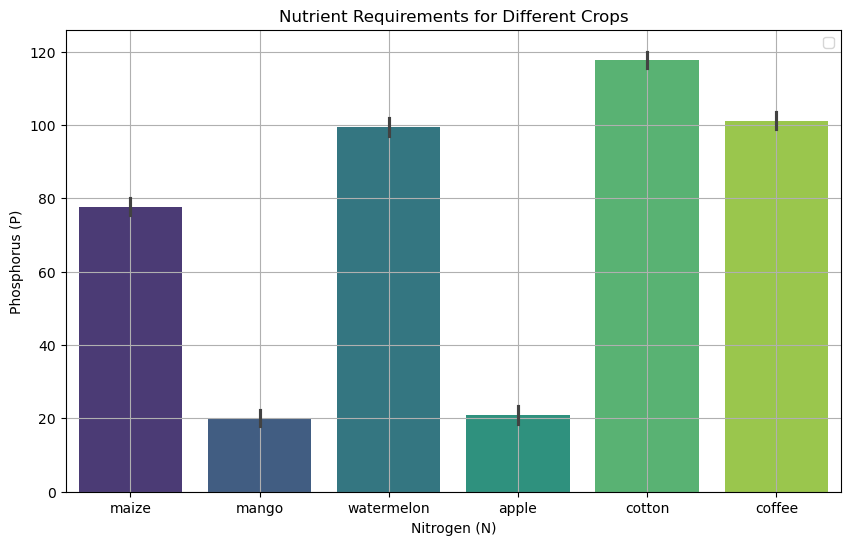

In [6]:
# Let's visualize the average nutrient requirement (N, P, K) for a few crops, to get a feel for the data
plt.figure(figsize=(10, 6))
sample_crops = ['mango', 'maize', 'cotton', 'coffee', 'apple','watermelon']
sns.barplot(x='label', y='N', data=df_reco[df_reco['label'].isin(sample_crops)], palette='viridis') 
plt.xlabel('Nitrogen (N)')
plt.ylabel('Phosphorus (P)')
plt.title('Nutrient Requirements for Different Crops')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Create and apply a LabelEncoder for the crop names
crop_label_encoder = LabelEncoder()
df_reco['label'] = crop_label_encoder.fit_transform(df_reco['label']) 

# Let's see a few crop-to-number mappings
for i, crop_name in enumerate(crop_label_encoder.classes_[:5]):
    print(f"{crop_name}: -> {i}")
print("........and so on, for all", len(crop_label_encoder.classes_), "crops.")

apple: -> 0
banana: -> 1
blackgram: -> 2
chickpea: -> 3
coconut: -> 4
........and so on, for all 22 crops.


In [8]:
reco_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall' ]

x_reco = df_reco[reco_features]
y_reco = df_reco['label']

# Split into 80% training, 20% testing
x_train_reco, x_test_reco, y_train_reco, y_test_reco = train_test_split(x_reco, y_reco, test_size=0.2, random_state=42)

print("Training data shape:", x_train_reco.shape[0])
print("Testing data shape:", x_test_reco.shape[0])

Training data shape: 1760
Testing data shape: 440


In [9]:
# Create the two models
reco_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

In [ ]:
https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv